<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Clifford_Dirac_Closure_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — V5 Minimal Clifford / Dirac Closure Test

This notebook continues the ECSM matter-sector ladder:

\[
(0,1,3)\;\text{packet}
\rightarrow
q_{\rm eff}\simeq -1
\rightarrow
p=\pm1
\rightarrow
\psi\in\mathbb{C}^2
\rightarrow
SU(2)/\text{Pauli closure}
\rightarrow
Cl(1,3)/\text{Dirac closure}.
\]

**Purpose of V5:** test whether the V3b/V4b electron-like packet scaffold can be lifted into a minimal Dirac/Clifford algebra representation.

This is **not** a full QED calculation and does **not** derive the physical electron mass. It is a controlled algebraic closure and dispersion test.

In [ ]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_electron_like_clifford_dirac_v5_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

def fro_norm(A):
    return float(np.linalg.norm(A))

def max_abs(A):
    return float(np.max(np.abs(A)))

print("Output folder:", OUT.resolve())

Output folder: /content/ecsm_electron_like_clifford_dirac_v5_out


## 1. Fixed V3b/V4b electron-like packet scaffold

We keep the previously recovered electron-like packet as the background scaffold.  
V5 uses a V3b/V4b-compatible smooth envelope with the published branch counts.

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V4b fixed V3b-like packet"
}


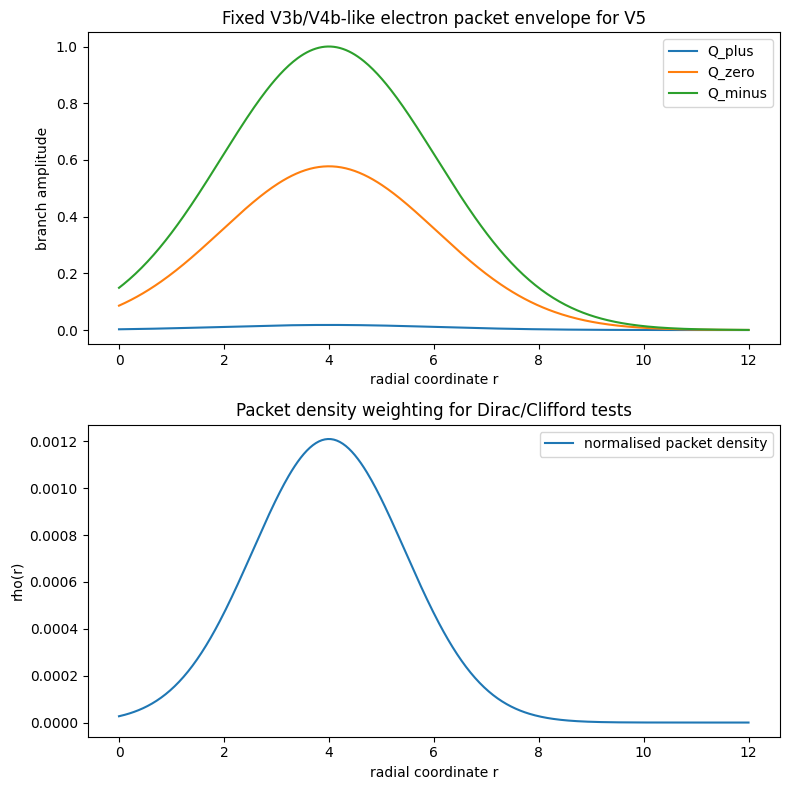

In [ ]:
# ============================================================
# CELL 2 — FIXED ELECTRON-LIKE PACKET ENVELOPE
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V4b fixed V3b-like packet"
}

N_grid = 420
r_max = 12.0
r = np.linspace(0, r_max, N_grid)
w = 4*np.pi*(r**2 + 1e-9)

center = 4.0
sigma = 2.05
env = np.exp(-0.5*((r-center)/sigma)**2)
env = env / (np.max(env) + 1e-15)

Qm = env
Q0 = np.sqrt(packet["N_zero"]/packet["N_minus"]) * env
Qp = np.sqrt(max(packet["N_plus"], 1e-15)/packet["N_minus"]) * env

dens = Qp**2 + Q0**2 + Qm**2
rho = dens / (np.trapezoid(w*dens, r) + 1e-15)

pd.DataFrame([packet]).to_csv(OUT/"fixed_packet_summary_v5.csv", index=False)
print(json.dumps(packet, indent=2))

fig, ax = plt.subplots(2, 1, figsize=(8, 8))
ax[0].plot(r, Qp, label="Q_plus")
ax[0].plot(r, Q0, label="Q_zero")
ax[0].plot(r, Qm, label="Q_minus")
ax[0].set_title("Fixed V3b/V4b-like electron packet envelope for V5")
ax[0].set_xlabel("radial coordinate r")
ax[0].set_ylabel("branch amplitude")
ax[0].legend()

ax[1].plot(r, rho, label="normalised packet density")
ax[1].set_title("Packet density weighting for Dirac/Clifford tests")
ax[1].set_xlabel("radial coordinate r")
ax[1].set_ylabel("rho(r)")
ax[1].legend()

plt.tight_layout()
plt.savefig(OUT/"fig_v5_fixed_packet_envelope.png", dpi=180)
plt.show()

## 2. Pauli layer inherited from V4b

V4b established a two-state internal orientation. V5 begins with the Pauli basis and lifts it into gamma matrices.

In [ ]:
# ============================================================
# CELL 3 — PAULI BASIS AND TWO-STATE ORIENTATION
# ============================================================

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

psi_plus = np.array([1,0], dtype=complex)
psi_minus = np.array([0,1], dtype=complex)

pauli_tests = {
    "plus_norm": float(np.vdot(psi_plus, psi_plus).real),
    "minus_norm": float(np.vdot(psi_minus, psi_minus).real),
    "orthogonality_abs": float(abs(np.vdot(psi_plus, psi_minus))),
    "anticomm_xy_norm": fro_norm(sigma_x@sigma_y + sigma_y@sigma_x),
    "anticomm_xx_minus_2I_norm": fro_norm(sigma_x@sigma_x + sigma_x@sigma_x - 2*I2),
    "comm_xy_minus_2i_sigmaz_norm": fro_norm(sigma_x@sigma_y - sigma_y@sigma_x - 2j*sigma_z),
}
pd.DataFrame([pauli_tests]).to_csv(OUT/"pauli_layer_tests_v5.csv", index=False)
print(json.dumps(pauli_tests, indent=2))

{
  "plus_norm": 1.0,
  "minus_norm": 1.0,
  "orthogonality_abs": 0.0,
  "anticomm_xy_norm": 0.0,
  "anticomm_xx_minus_2I_norm": 0.0,
  "comm_xy_minus_2i_sigmaz_norm": 0.0
}


## 3. Dirac gamma matrices and Clifford closure

Use the standard Dirac representation with signature:

\[
\eta_{\mu\nu}=\mathrm{diag}(+1,-1,-1,-1).
\]

Target:

\[
\{\gamma^\mu,\gamma^\nu\}=2\eta^{\mu\nu}I_4.
\]

 mu  nu  eta_munu  closure_error_fro  closure_error_max_abs
  0   0         1                0.0                    0.0
  0   1         0                0.0                    0.0
  0   2         0                0.0                    0.0
  0   3         0                0.0                    0.0
  1   0         0                0.0                    0.0
  1   1        -1                0.0                    0.0
  1   2         0                0.0                    0.0
  1   3         0                0.0                    0.0
  2   0         0                0.0                    0.0
  2   1         0                0.0                    0.0
  2   2        -1                0.0                    0.0
  2   3         0                0.0                    0.0
  3   0         0                0.0                    0.0
  3   1         0                0.0                    0.0
  3   2         0                0.0                    0.0
  3   3        -1                0.0    

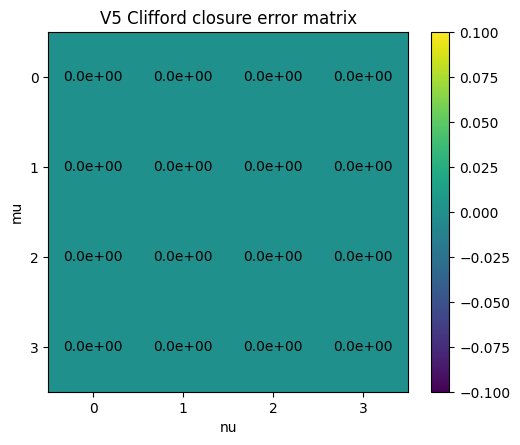

In [ ]:
# ============================================================
# CELL 4 — GAMMA MATRICES / CLIFFORD CLOSURE
# ============================================================

I4 = np.eye(4, dtype=complex)
Z4 = np.zeros((4,4), dtype=complex)

gamma0 = np.block([[I2, Z2], [Z2, -I2]])
gamma1 = np.block([[Z2, sigma_x], [-sigma_x, Z2]])
gamma2 = np.block([[Z2, sigma_y], [-sigma_y, Z2]])
gamma3 = np.block([[Z2, sigma_z], [-sigma_z, Z2]])

gammas = [gamma0, gamma1, gamma2, gamma3]
eta = np.diag([1,-1,-1,-1])

closure_rows = []
closure_matrix = np.zeros((4,4))

for mu in range(4):
    for nu in range(4):
        anti = gammas[mu]@gammas[nu] + gammas[nu]@gammas[mu]
        target = 2*eta[mu,nu]*I4
        err = fro_norm(anti - target)
        closure_matrix[mu,nu] = err
        closure_rows.append({
            "mu": mu,
            "nu": nu,
            "eta_munu": eta[mu,nu],
            "closure_error_fro": err,
            "closure_error_max_abs": max_abs(anti-target)
        })

closure = pd.DataFrame(closure_rows)
closure.to_csv(OUT/"clifford_closure_tests_v5.csv", index=False)

print(closure.to_string(index=False))
print("\nMax Clifford closure error:", closure["closure_error_fro"].max())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(closure_matrix)
ax.set_title("V5 Clifford closure error matrix")
ax.set_xlabel("nu")
ax.set_ylabel("mu")
ax.set_xticks(range(4))
ax.set_yticks(range(4))
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{closure_matrix[i,j]:.1e}", ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUT/"fig_v5_clifford_closure_error_matrix.png", dpi=180)
plt.show()

## 4. Dirac alpha/beta matrices and response-locking mass

Minimal Dirac Hamiltonian:

\[
H(\mathbf{k}) = \boldsymbol{\alpha}\cdot\mathbf{k} + \beta m_{\rm lock}.
\]

Here \(m_{\rm lock}\) is a **dimensionless response-locking mass parameter** tied schematically to the V3b packet energy. It is not the physical electron mass.

m_lock (dimensionless toy response-lock scale): 0.225463435330576
                test  error
         alpha_1^2=I    0.0
   {alpha_1, beta}=0    0.0
         alpha_2^2=I    0.0
   {alpha_2, beta}=0    0.0
         alpha_3^2=I    0.0
   {alpha_3, beta}=0    0.0
{alpha_1, alpha_2}=0    0.0
{alpha_1, alpha_3}=0    0.0
{alpha_2, alpha_3}=0    0.0
            beta^2=I    0.0

Dispersion summary:
    k        E1        E2       E3       E4  target_positive  max_branch_error  branch_symmetry_error
0.000 -0.225463 -0.225463 0.225463 0.225463         0.225463      0.000000e+00                    0.0
0.025 -0.226845 -0.226845 0.226845 0.226845         0.226845      2.775558e-17                    0.0
0.050 -0.230941 -0.230941 0.230941 0.230941         0.230941      0.000000e+00                    0.0
0.075 -0.237611 -0.237611 0.237611 0.237611         0.237611      2.775558e-17                    0.0
0.100 -0.246645 -0.246645 0.246645 0.246645         0.246645      2.775558e-17                 

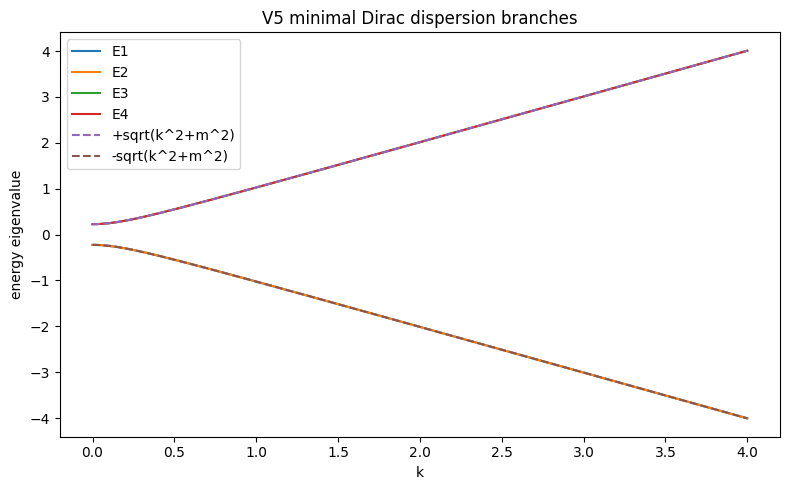

In [ ]:
# ============================================================
# CELL 5 — DIRAC HAMILTONIAN AND DISPERSION
# ============================================================

alpha1 = gamma0 @ gamma1
alpha2 = gamma0 @ gamma2
alpha3 = gamma0 @ gamma3
beta = gamma0
alphas = [alpha1, alpha2, alpha3]

E_packet_v3b = 0.05083376067106482
m_lock = float(np.sqrt(E_packet_v3b))
print("m_lock (dimensionless toy response-lock scale):", m_lock)

ab_rows = []
for i, A in enumerate(alphas):
    ab_rows.append({"test": f"alpha_{i+1}^2=I", "error": fro_norm(A@A - I4)})
    ab_rows.append({"test": f"{{alpha_{i+1}, beta}}=0", "error": fro_norm(A@beta + beta@A)})
for i in range(3):
    for j in range(i+1,3):
        ab_rows.append({"test": f"{{alpha_{i+1}, alpha_{j+1}}}=0", "error": fro_norm(alphas[i]@alphas[j] + alphas[j]@alphas[i])})
ab_rows.append({"test": "beta^2=I", "error": fro_norm(beta@beta - I4)})

ab = pd.DataFrame(ab_rows)
ab.to_csv(OUT/"alpha_beta_algebra_tests_v5.csv", index=False)
print(ab.to_string(index=False))

def H_dirac(kvec, m=m_lock):
    kx, ky, kz = kvec
    return kx*alpha1 + ky*alpha2 + kz*alpha3 + m*beta

k_vals = np.linspace(0, 4, 161)
disp_rows = []

for k in k_vals:
    H = H_dirac((k,0,0), m_lock)
    eigs = np.linalg.eigvalsh(H)
    eigs = np.sort(np.real(eigs))
    target = np.sqrt(k*k + m_lock*m_lock)
    disp_rows.append({
        "k": k,
        "E1": eigs[0],
        "E2": eigs[1],
        "E3": eigs[2],
        "E4": eigs[3],
        "target_negative": -target,
        "target_positive": target,
        "max_branch_error": max(abs(eigs[0]+target), abs(eigs[1]+target), abs(eigs[2]-target), abs(eigs[3]-target)),
        "branch_symmetry_error": max(abs(eigs[0]+eigs[3]), abs(eigs[1]+eigs[2]))
    })

disp = pd.DataFrame(disp_rows)
disp.to_csv(OUT/"dirac_dispersion_scan_v5.csv", index=False)

print("\nDispersion summary:")
print(disp[["k","E1","E2","E3","E4","target_positive","max_branch_error","branch_symmetry_error"]].head().to_string(index=False))
print("Max branch error:", disp["max_branch_error"].max())
print("Max symmetry error:", disp["branch_symmetry_error"].max())

fig, ax = plt.subplots(figsize=(8,5))
for col in ["E1","E2","E3","E4"]:
    ax.plot(disp["k"], disp[col], label=col)
ax.plot(disp["k"], disp["target_positive"], "--", label="+sqrt(k^2+m^2)")
ax.plot(disp["k"], disp["target_negative"], "--", label="-sqrt(k^2+m^2)")
ax.set_xlabel("k")
ax.set_ylabel("energy eigenvalue")
ax.set_title("V5 minimal Dirac dispersion branches")
ax.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_v5_dirac_dispersion_branches.png", dpi=180)
plt.show()

## 5. Response-deformed Clifford test

A schematic ECSM deformation:

\[
\Gamma^i_\chi = \sqrt{\chi}\gamma^i,
\qquad
g^{00}_{\rm eff}=1,
\qquad
g^{ii}_{\rm eff}=-\chi.
\]

Test:

\[
\{\Gamma^\mu_\chi,\Gamma^\nu_\chi\}=2g^{\mu\nu}_{\rm eff}I.
\]

 chi  sqrt_chi  max_deformed_closure_error  mean_deformed_closure_error
1.00  1.000000                0.000000e+00                 0.000000e+00
0.95  0.974679                4.440892e-16                 8.326673e-17
0.80  0.894427                4.440892e-16                 8.326673e-17
0.50  0.707107                4.440892e-16                 8.326673e-17
0.20  0.447214                1.110223e-16                 2.081668e-17


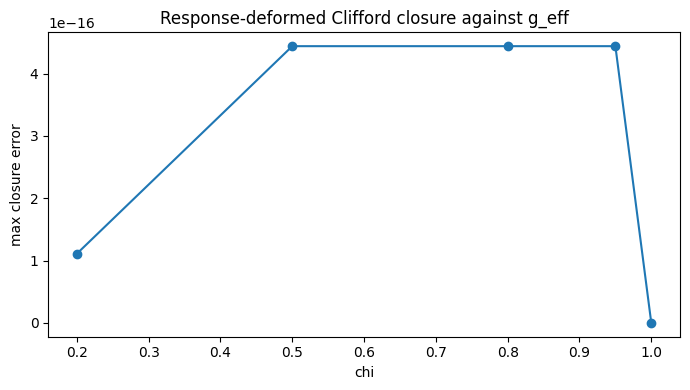

In [ ]:
# ============================================================
# CELL 6 — RESPONSE-DEFORMED CLIFFORD CLOSURE
# ============================================================

chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
chi_rows = []

for chi in chi_values:
    c = np.sqrt(chi)
    G = [gamma0, c*gamma1, c*gamma2, c*gamma3]
    g_eff = np.diag([1, -chi, -chi, -chi])
    max_err = 0.0
    mean_err = 0.0
    n = 0
    for mu in range(4):
        for nu in range(4):
            anti = G[mu]@G[nu] + G[nu]@G[mu]
            target = 2*g_eff[mu,nu]*I4
            err = fro_norm(anti-target)
            max_err = max(max_err, err)
            mean_err += err
            n += 1
    mean_err /= n
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": c,
        "max_deformed_closure_error": max_err,
        "mean_deformed_closure_error": mean_err
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT/"response_deformed_clifford_tests_v5.csv", index=False)
print(chi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(chi_df["chi"], chi_df["max_deformed_closure_error"], marker="o")
ax.set_xlabel("chi")
ax.set_ylabel("max closure error")
ax.set_title("Response-deformed Clifford closure against g_eff")
plt.tight_layout()
plt.savefig(OUT/"fig_v5_response_deformed_clifford_error.png", dpi=180)
plt.show()

## 6. Packet-hosted Dirac spinor modes

Construct simple packet-hosted four-spinor modes by multiplying the radial packet envelope by positive and negative energy eigenspinors.

{
  "k0": 1.0,
  "E_negative": -1.0251018294155294,
  "E_positive": 1.0251018294155294,
  "packet_spinor_norm_positive": 1.0,
  "packet_spinor_norm_negative": 1.0,
  "packet_spinor_overlap_abs": 0.0,
  "branch_symmetry_abs": 0.0
}


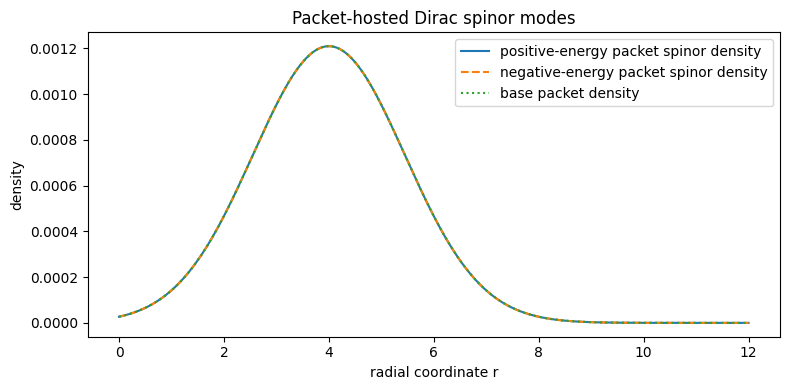

In [ ]:
# ============================================================
# CELL 7 — PACKET-HOSTED FOUR-SPINOR MODES
# ============================================================

k0 = 1.0
H0 = H_dirac((k0,0,0), m_lock)
evals, evecs = np.linalg.eigh(H0)
idx = np.argsort(np.real(evals))
evals = np.real(evals[idx])
evecs = evecs[:,idx]

u_neg = evecs[:,0]
u_pos = evecs[:,-1]
u_neg = u_neg/np.sqrt(np.vdot(u_neg,u_neg))
u_pos = u_pos/np.sqrt(np.vdot(u_pos,u_pos))

amp = np.sqrt(rho)
Psi_pos = np.outer(amp, u_pos)
Psi_neg = np.outer(amp, u_neg)

density_pos = np.sum(np.abs(Psi_pos)**2, axis=1)
density_neg = np.sum(np.abs(Psi_neg)**2, axis=1)

norm_pos = float(np.trapezoid(w*density_pos, r))
norm_neg = float(np.trapezoid(w*density_neg, r))
overlap = complex(np.trapezoid(w*np.sum(np.conjugate(Psi_pos)*Psi_neg, axis=1), r))

mode_summary = {
    "k0": k0,
    "E_negative": float(evals[0]),
    "E_positive": float(evals[-1]),
    "packet_spinor_norm_positive": norm_pos,
    "packet_spinor_norm_negative": norm_neg,
    "packet_spinor_overlap_abs": float(abs(overlap)),
    "branch_symmetry_abs": float(abs(evals[0]+evals[-1]))
}
pd.DataFrame([mode_summary]).to_csv(OUT/"packet_hosted_spinor_modes_v5.csv", index=False)
print(json.dumps(mode_summary, indent=2))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(r, density_pos, label="positive-energy packet spinor density")
ax.plot(r, density_neg, "--", label="negative-energy packet spinor density")
ax.plot(r, rho, ":", label="base packet density")
ax.set_xlabel("radial coordinate r")
ax.set_ylabel("density")
ax.set_title("Packet-hosted Dirac spinor modes")
ax.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_v5_packet_hosted_spinor_modes.png", dpi=180)
plt.show()

## 7. Final V5 verdict

A clean V5 pass means:

\[
(0,1,3)\text{ packet}
\rightarrow
q_{\rm eff}\simeq -1
\rightarrow
p=\pm1
\rightarrow
SU(2)
\rightarrow
Cl(1,3)
\rightarrow
\text{minimal Dirac branch structure}.
\]

In [ ]:
# ============================================================
# CELL 8 — FINAL VERDICT TABLE
# ============================================================

clifford_max = float(closure["closure_error_fro"].max())
alpha_beta_max = float(ab["error"].max())
disp_max = float(disp["max_branch_error"].max())
sym_max = float(disp["branch_symmetry_error"].max())
chi_closure_max = float(chi_df["max_deformed_closure_error"].max())
mode_norm_error = max(abs(norm_pos-1), abs(norm_neg-1))

pauli_max = max(
    pauli_tests["anticomm_xy_norm"],
    pauli_tests["anticomm_xx_minus_2I_norm"],
    pauli_tests["comm_xy_minus_2i_sigmaz_norm"]
)

verdict_rows = [
    ("packet remains q=-1", abs(packet["q_eff"] + 1), abs(packet["q_eff"] + 1) < 0.01),
    ("packet N_plus near 0", abs(packet["N_plus"] - 0), abs(packet["N_plus"] - 0) < 0.01),
    ("packet N_zero near 1", abs(packet["N_zero"] - 1), abs(packet["N_zero"] - 1) < 0.01),
    ("packet N_minus near 3", abs(packet["N_minus"] - 3), abs(packet["N_minus"] - 3) < 0.01),
    ("Pauli layer closure", pauli_max, pauli_max < 1e-12),
    ("Clifford gamma closure", clifford_max, clifford_max < 1e-12),
    ("alpha/beta algebra closure", alpha_beta_max, alpha_beta_max < 1e-12),
    ("Dirac dispersion branches", disp_max, disp_max < 1e-12),
    ("positive/negative branch symmetry", sym_max, sym_max < 1e-12),
    ("response-deformed Clifford closure", chi_closure_max, chi_closure_max < 1e-12),
    ("packet-hosted spinor modes normalised", mode_norm_error, mode_norm_error < 1e-12),
    ("packet-hosted pos/neg modes orthogonal", abs(overlap), abs(overlap) < 1e-12),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion", "value", "pass"])
verdict.to_csv(OUT/"final_clifford_dirac_v5_verdict.csv", index=False)

n_pass = int(verdict["pass"].sum())
n_criteria = int(len(verdict))
final_label = "PASS: minimal Clifford/Dirac closure scaffold on V3b/V4b electron-like packet" if n_pass == n_criteria else "CONDITIONAL/FAIL: Clifford/Dirac closure incomplete"

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet["q_eff"],
    "m_lock_dimensionless": m_lock,
    "clifford_max_error": clifford_max,
    "alpha_beta_max_error": alpha_beta_max,
    "dirac_dispersion_max_error": disp_max,
    "branch_symmetry_max_error": sym_max,
    "response_deformed_closure_max_error": chi_closure_max,
    "packet_spinor_norm_error": mode_norm_error,
    "packet_spinor_overlap_abs": float(abs(overlap)),
}
with open(OUT/"run_summary_v5.json", "w") as f:
    json.dump(summary, f, indent=2)

print(verdict.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))

files = sorted([p.name for p in OUT.iterdir()])
pd.DataFrame({"file": files}).to_csv(OUT/"manifest_v5.csv", index=False)
pd.DataFrame({"file": files})

                             criterion        value  pass
                   packet remains q=-1 6.964280e-04  True
                  packet N_plus near 0 9.716379e-04  True
                  packet N_zero near 1 1.460081e-04  True
                 packet N_minus near 3 1.117646e-03  True
                   Pauli layer closure 0.000000e+00  True
                Clifford gamma closure 0.000000e+00  True
            alpha/beta algebra closure 0.000000e+00  True
             Dirac dispersion branches 1.332268e-15  True
     positive/negative branch symmetry 1.332268e-15  True
    response-deformed Clifford closure 4.440892e-16  True
 packet-hosted spinor modes normalised 0.000000e+00  True
packet-hosted pos/neg modes orthogonal 0.000000e+00  True

Final label: PASS: minimal Clifford/Dirac closure scaffold on V3b/V4b electron-like packet
{
  "final_label": "PASS: minimal Clifford/Dirac closure scaffold on V3b/V4b electron-like packet",
  "n_pass": 12,
  "n_criteria": 12,
  "q_eff": -0.9993

,file
0,alpha_beta_algebra_tests_v5.csv
1,clifford_closure_tests_v5.csv
2,dirac_dispersion_scan_v5.csv
3,fig_v5_clifford_closure_error_matrix.png
4,fig_v5_dirac_dispersion_branches.png
5,fig_v5_fixed_packet_envelope.png
6,fig_v5_packet_hosted_spinor_modes.png
7,fig_v5_response_deformed_clifford_error.png
8,final_clifford_dirac_v5_verdict.csv
9,fixed_packet_summary_v5.csv


## V5 interpretation

This should be interpreted cautiously. It is an **algebraic closure and toy dispersion test**, not a derivation of QED, \(g-2\), physical spin-statistics, or the measured electron mass.